# Exploratory Analysis of Bitcoin Returns

## 1. Exploratory Data Analysis


In [ ]:
from pathlib import Path
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.4f}".format

In [3]:
DATA_PATH = Path("data/BTC/BTC_USD_coinbase_spot_daily_features.csv")
METADATA_PATH = Path("data/BTC/BTC_USD_coinbase_spot_daily_features.metadata.json")
SCALER_PATH = Path("data/BTC/BTC_USD_coinbase_spot_daily_features.scaler.pkl")

In [4]:
daily_scaled = pd.read_csv(DATA_PATH, parse_dates=["timestamp_utc"])

with METADATA_PATH.open("r", encoding="utf-8") as file:
    metadata = json.load(file)

with SCALER_PATH.open("rb") as file:
    scaler = pickle.load(file)

scaled_columns = metadata["scaled_columns"]
daily_full = daily_scaled.copy()
daily_full[scaled_columns] = scaler.inverse_transform(daily_scaled[scaled_columns])

daily_full = daily_full.set_index("timestamp_utc").sort_index()
daily_full.head()

,open,high,low,close,volume,product_id,source,observations,expected_observations,coverage_ratio,...,volume_log_lag_1,log_return_lag_2,volume_log_lag_2,log_return_lag_3,volume_log_lag_3,log_return_lag_7,volume_log_lag_7,target_log_return_next,target_direction_next,split
timestamp_utc,,,,,,,,,,,,,,,,,,,,,
2016-05-14 00:00:00+00:00,457.9700,459.8300,456.0000,458.9000,"3,295.1997",BTC-USD,coinbase_exchange_spot,288,288,1.0000,...,8.5951,0.0046,8.7193,0.0035,8.6565,-0.0009,8.1504,0.0056,1.0000,train
2016-05-15 00:00:00+00:00,458.9000,463.6200,458.4900,461.4700,"3,269.9825",BTC-USD,coinbase_exchange_spot,288,288,1.0000,...,8.1005,0.0033,8.5951,0.0046,8.7193,0.0019,8.0946,-0.0127,0.0000,train
2016-05-16 00:00:00+00:00,461.4800,461.5900,451.4800,455.6600,"6,019.1724",BTC-USD,coinbase_exchange_spot,288,288,1.0000,...,8.0928,0.0020,8.1005,0.0033,8.5951,0.0030,8.6800,-0.0032,0.0000,train
2016-05-17 00:00:00+00:00,455.6400,457.4900,452.2000,454.1900,"6,033.9084",BTC-USD,coinbase_exchange_spot,288,288,1.0000,...,8.7029,0.0056,8.0928,0.0020,8.1005,-0.0248,8.8269,0.0030,1.0000,train
2016-05-18 00:00:00+00:00,454.1900,457.8800,453.6000,455.5600,"5,512.4238",BTC-USD,coinbase_exchange_spot,288,288,1.0000,...,8.7053,-0.0127,8.7029,0.0056,8.0928,0.0035,8.6565,-0.0384,0.0000,train


### Dataset overview

In [5]:
train_daily = daily_full.loc[daily_full["split"] == "train"].copy()
test_daily = daily_full.loc[daily_full["split"] == "test"].copy()

# Use only the training split for the exploratory and statistical analysis below
daily = train_daily.copy()

print(f"Full rows: {len(daily_full):,}")
print(f"Training rows used below: {len(daily):,}")
print(f"Test rows held out: {len(test_daily):,}")
print(f"Columns: {daily_full.shape[1]}")
print(f"Training start date: {daily.index.min().date()}")
print(f"Training end date: {daily.index.max().date()}")
print(f"Test start date: {test_daily.index.min().date()}")
print(f"Test end date: {test_daily.index.max().date()}")
print(f"Training missing values: {daily.isna().sum().sum()}")
print(f"Duplicated dates in full data: {daily_full.index.duplicated().sum()}")

Full rows: 3,595
Training rows used below: 2,876
Test rows held out: 719
Columns: 42
Training start date: 2016-05-14
Training end date: 2024-04-21
Test start date: 2024-04-22
Test end date: 2026-04-11
Training missing values: 0
Duplicated dates in full data: 0


In [6]:
daily[[
    "open",
    "high",
    "low",
    "close",
    "volume",
    "log_return",
    "split",
]].head()

,open,high,low,close,volume,log_return,split
timestamp_utc,,,,,,,
2016-05-14 00:00:00+00:00,457.9700,459.8300,456.0000,458.9000,"3,295.1997",0.0020,train
2016-05-15 00:00:00+00:00,458.9000,463.6200,458.4900,461.4700,"3,269.9825",0.0056,train
2016-05-16 00:00:00+00:00,461.4800,461.5900,451.4800,455.6600,"6,019.1724",-0.0127,train
2016-05-17 00:00:00+00:00,455.6400,457.4900,452.2000,454.1900,"6,033.9084",-0.0032,train
2016-05-18 00:00:00+00:00,454.1900,457.8800,453.6000,455.5600,"5,512.4238",0.0030,train


### Missing values and daily coverage

In [7]:
missing_values = daily.isna().sum().to_frame("missing_values")
missing_values["missing_share"] = missing_values["missing_values"] / len(daily)

missing_values[missing_values["missing_values"] > 0]

,missing_values,missing_share


In [8]:
daily[["observations", "expected_observations", "coverage_ratio"]].describe().T

,count,mean,std,min,25%,50%,75%,max
observations,"2,876.0000",287.8832,0.9149,274.0000,288.0000,288.0000,288.0000,288.0000
expected_observations,"2,876.0000",288.0000,0.0000,288.0000,288.0000,288.0000,288.0000,288.0000
coverage_ratio,"2,876.0000",0.9996,0.0032,0.9514,1.0000,1.0000,1.0000,1.0000


In [9]:
# Most rows should be exactly one day apart
date_gaps = daily.index.to_series().diff()
date_gaps.value_counts().head(10)

timestamp_utc
1 days    2854
2 days      19
3 days       1
4 days       1
Name: count, dtype: int64

In the daily data we have gaps that were not present in the 5min data.

In [10]:
long_gaps = date_gaps[date_gaps > pd.Timedelta(days=1)]

gap_details = pd.DataFrame({
    "previous_date": [daily.index[daily.index.get_loc(date) - 1] for date in long_gaps.index],
    "current_date": long_gaps.index,
    "gap_length": long_gaps.values,
})

gap_details.head(30)

,previous_date,current_date,gap_length
0,2016-07-10 00:00:00+00:00,2016-07-12 00:00:00+00:00,2 days
1,2016-09-18 00:00:00+00:00,2016-09-20 00:00:00+00:00,2 days
2,2016-10-14 00:00:00+00:00,2016-10-17 00:00:00+00:00,3 days
3,2017-01-15 00:00:00+00:00,2017-01-17 00:00:00+00:00,2 days
4,2017-02-27 00:00:00+00:00,2017-03-03 00:00:00+00:00,4 days
5,2017-04-14 00:00:00+00:00,2017-04-16 00:00:00+00:00,2 days
6,2017-09-24 00:00:00+00:00,2017-09-26 00:00:00+00:00,2 days
7,2017-11-30 00:00:00+00:00,2017-12-02 00:00:00+00:00,2 days
8,2017-12-11 00:00:00+00:00,2017-12-13 00:00:00+00:00,2 days
9,2018-01-31 00:00:00+00:00,2018-02-02 00:00:00+00:00,2 days


### Summary statistics

In [11]:
main_columns = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "log_return",
    "simple_return",
    "high_low_range",
]

daily[main_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
open,"2,876.0000","19,230.3015","17,750.2279",437.9100,"6,182.2125","10,761.1450","29,944.3950","73,135.0400"
high,"2,876.0000","19,724.1113","18,205.6869",445.8500,"6,327.0850","11,042.0000","30,514.1875","73,835.5700"
low,"2,876.0000","18,689.4249","17,240.9554",435.0000,"5,915.9075","10,357.8250","29,366.2375","71,337.3000"
close,"2,876.0000","19,252.5778","17,767.2392",438.3800,"6,187.5650","10,761.1450","29,997.3475","73,135.0400"
volume,"2,876.0000","15,382.9688","12,024.1766","1,315.7296","7,307.8385","12,412.8030","19,570.0205","130,316.6468"
log_return,"2,876.0000",0.0017,0.0386,-0.4912,-0.0133,0.0016,0.0183,0.2406
simple_return,"2,876.0000",0.0025,0.0383,-0.3881,-0.0132,0.0016,0.0185,0.2720
high_low_range,"2,876.0000",0.0533,0.0435,0.0040,0.0260,0.0424,0.0657,0.6847


In [12]:
largest_gain_date = daily["log_return"].idxmax()
largest_loss_date = daily["log_return"].idxmin()

print("Largest daily log-return gain:")
print(largest_gain_date.date(), round(daily.loc[largest_gain_date, "log_return"], 4))

print("\nLargest daily log-return loss:")
print(largest_loss_date.date(), round(daily.loc[largest_loss_date, "log_return"], 4))

Largest daily log-return gain:
2017-07-20 0.2406

Largest daily log-return loss:
2020-03-12 -0.4912


### Price and volume

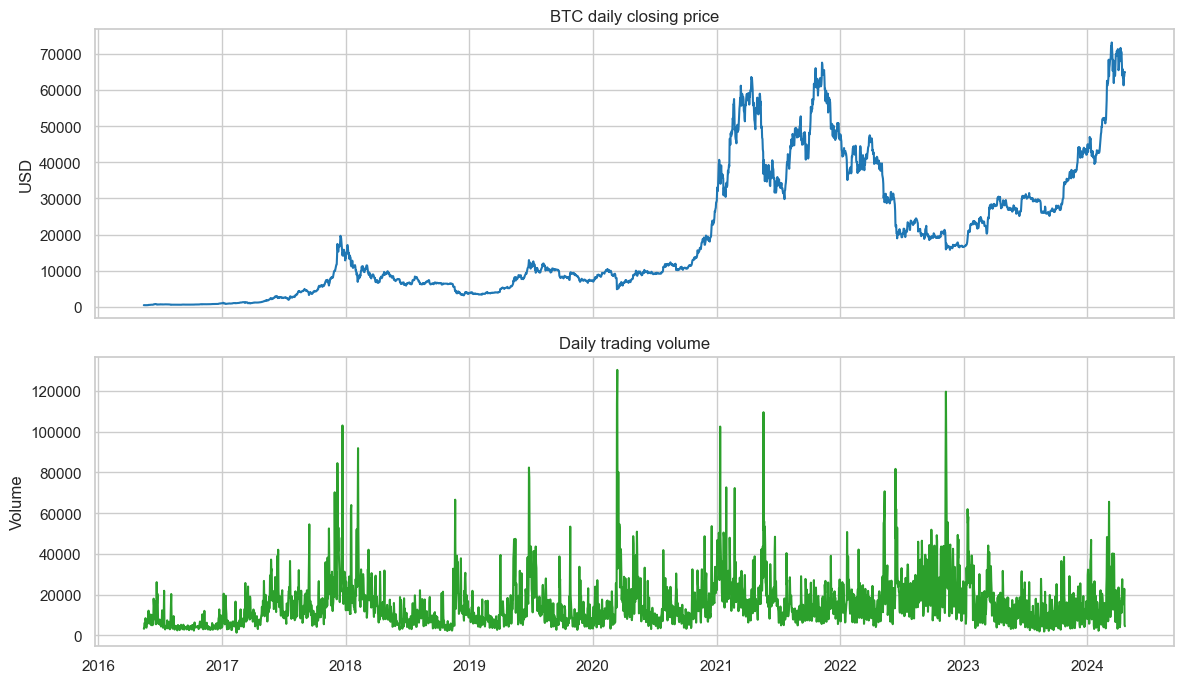

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(daily.index, daily["close"], color="tab:blue")
axes[0].set_title("BTC daily closing price")
axes[0].set_ylabel("USD")

axes[1].plot(daily.index, daily["volume"], color="tab:green")
axes[1].set_title("Daily trading volume")
axes[1].set_ylabel("Volume")

plt.tight_layout()
plt.show()

### Daily returns

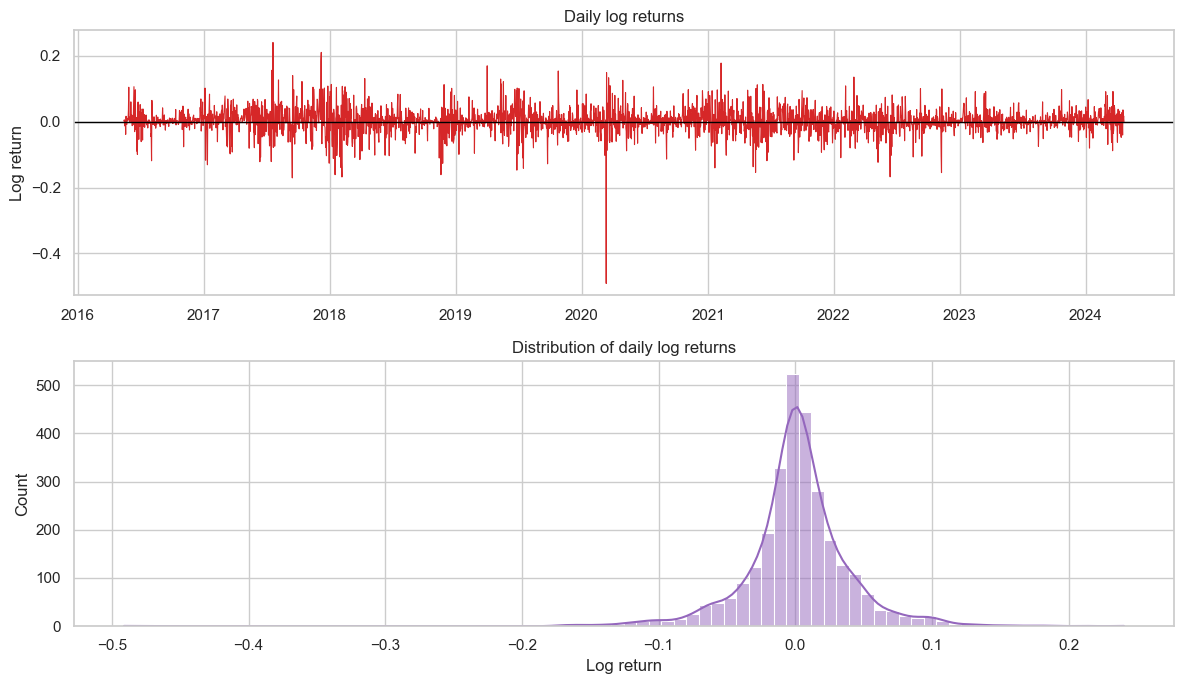

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(daily.index, daily["log_return"], color="tab:red", linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Daily log returns")
axes[0].set_ylabel("Log return")

sns.histplot(daily["log_return"], bins=80, kde=True, ax=axes[1], color="tab:purple")
axes[1].set_title("Distribution of daily log returns")
axes[1].set_xlabel("Log return")

plt.tight_layout()
plt.show()

## 2. Trend, Seasonality, and Volatility

This section checks how the daily BTC series behaves over time. We look at the price trend, simple calendar patterns, and changing volatility.

### Trend

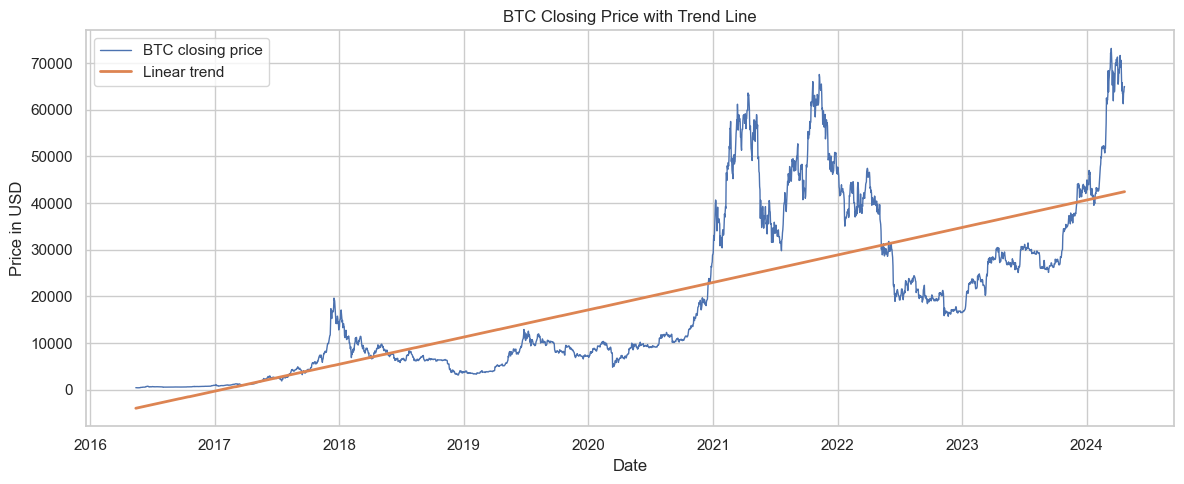

In [15]:
trend_data = daily["close"].dropna()

x = np.arange(len(trend_data))

trend_coef = np.polyfit(x, trend_data, 1)
trend_line = np.polyval(trend_coef, x)

plt.figure(figsize=(12, 5))

plt.plot(trend_data.index, trend_data, label="BTC closing price", linewidth=1)
plt.plot(trend_data.index, trend_line, label="Linear trend", linewidth=2)

plt.title("BTC Closing Price with Trend Line")
plt.xlabel("Date")
plt.ylabel("Price in USD")
plt.legend()
plt.tight_layout()
plt.show()

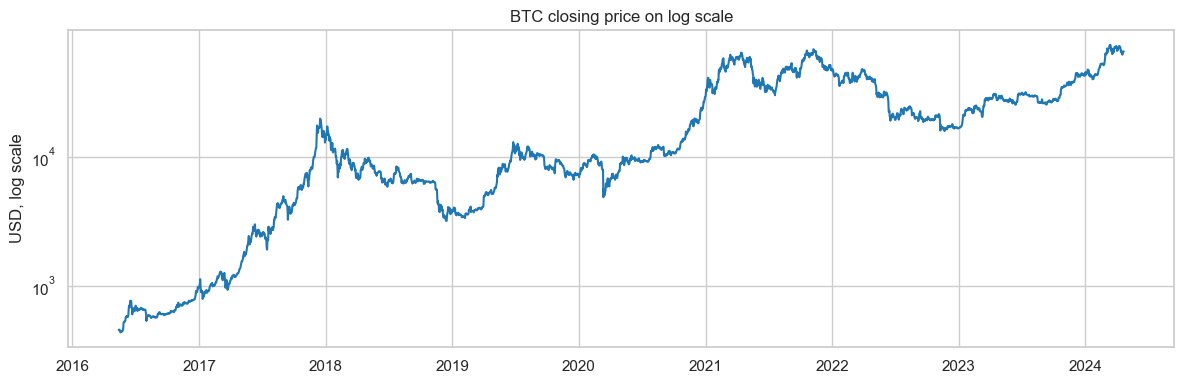

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily["close"], color="tab:blue")
plt.yscale("log")
plt.title("BTC closing price on log scale")
plt.ylabel("USD, log scale")
plt.tight_layout()
plt.show()

### Seasonality

In [17]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

daily["weekday"] = daily.index.day_name()
daily["month"] = daily.index.month_name()

weekday_summary = daily.groupby("weekday")["log_return"].agg(
    days="count",
    mean_return="mean",
    median_return="median",
    volatility="std",
).reindex(weekday_order)

weekday_summary

,days,mean_return,median_return,volatility
weekday,,,,
Monday,409,0.0038,0.0001,0.0422
Tuesday,411,0.0008,0.0023,0.0368
Wednesday,412,0.0033,0.0030,0.0406
Thursday,406,-0.0009,-0.0008,0.0487
Friday,412,0.0017,0.0029,0.0384
Saturday,412,0.0030,0.0020,0.0299
Sunday,414,0.0002,0.0001,0.0299


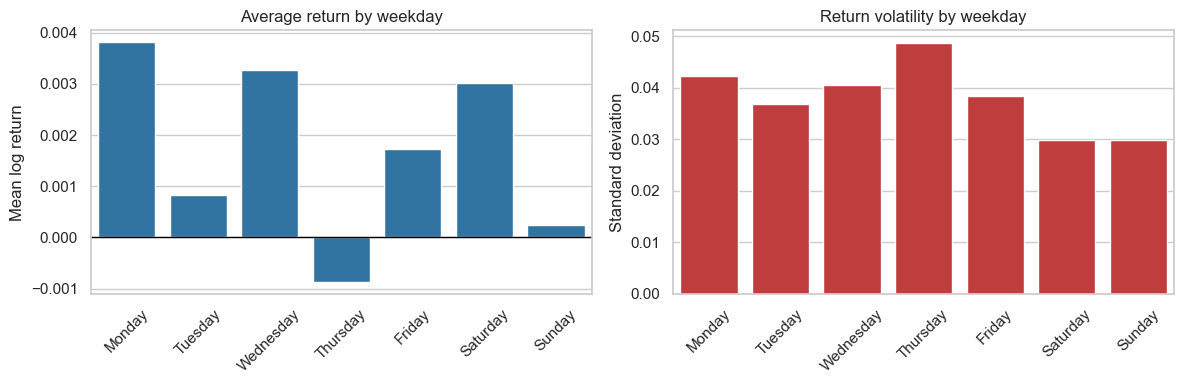

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=weekday_summary.reset_index(),
    x="weekday",
    y="mean_return",
    ax=axes[0],
    color="tab:blue",
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Average return by weekday")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean log return")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=weekday_summary.reset_index(),
    x="weekday",
    y="volatility",
    ax=axes[1],
    color="tab:red",
)
axes[1].set_title("Return volatility by weekday")
axes[1].set_xlabel("")
axes[1].set_ylabel("Standard deviation")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [19]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

monthly_summary = daily.groupby("month")["log_return"].agg(
    days="count",
    mean_return="mean",
    volatility="std",
).reindex(month_order)

monthly_summary

,days,mean_return,volatility
month,,,
January,246,0.0006,0.0406
February,224,0.0046,0.0411
March,245,-0.0001,0.0520
April,229,0.0035,0.0326
May,234,0.0015,0.0409
June,238,-0.0003,0.0437
July,247,0.0029,0.0379
August,247,0.0006,0.0299
September,238,-0.0016,0.0332


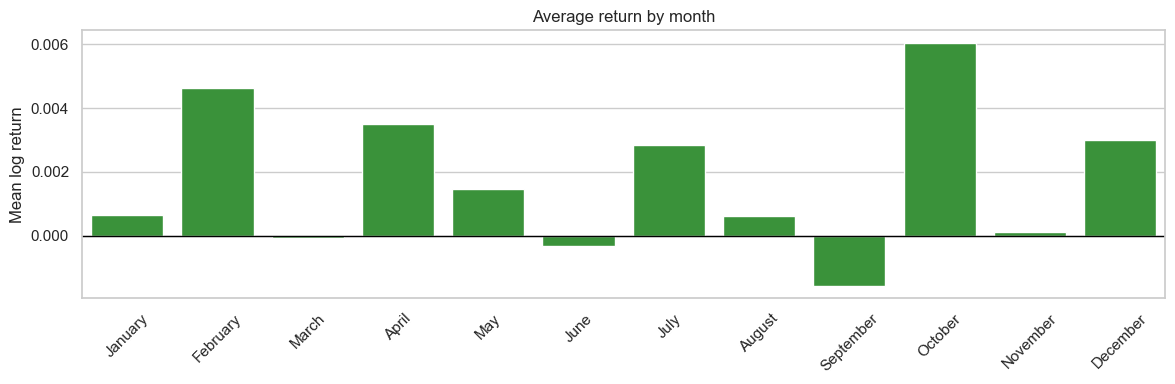

In [20]:
plt.figure(figsize=(12, 4))
sns.barplot(
    data=monthly_summary.reset_index(),
    x="month",
    y="mean_return",
    color="tab:green",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Average return by month")
plt.xlabel("")
plt.ylabel("Mean log return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Volatility

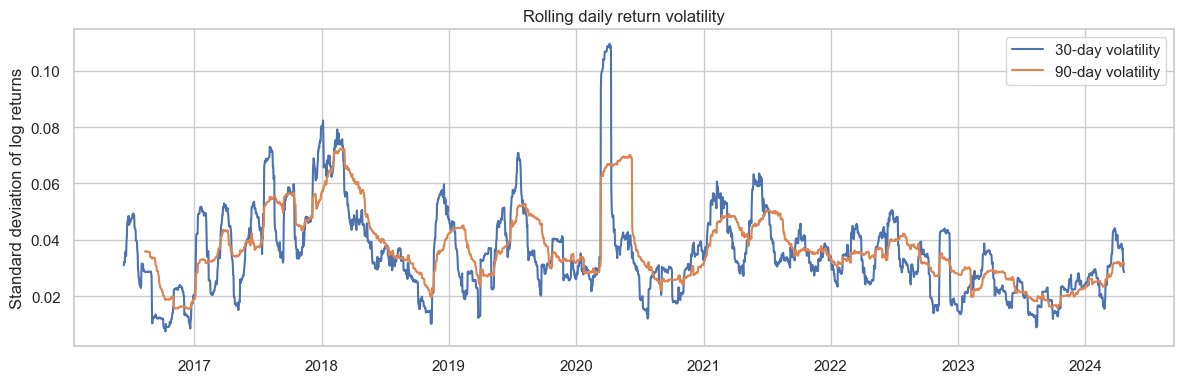

In [21]:
daily["volatility_30_eda"] = daily["log_return"].rolling(30).std()
daily["volatility_90_eda"] = daily["log_return"].rolling(90).std()

plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily["volatility_30_eda"], label="30-day volatility")
plt.plot(daily.index, daily["volatility_90_eda"], label="90-day volatility")
plt.title("Rolling daily return volatility")
plt.ylabel("Standard deviation of log returns")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
volatility_summary = daily[["log_return", "volatility_30_eda", "volatility_90_eda"]].describe().T
volatility_summary

,count,mean,std,min,25%,50%,75%,max
log_return,"2,876.0000",0.0017,0.0386,-0.4912,-0.0133,0.0016,0.0183,0.2406
volatility_30_eda,"2,847.0000",0.0353,0.0156,0.0075,0.0251,0.0329,0.0431,0.1096
volatility_90_eda,"2,787.0000",0.0365,0.0124,0.0155,0.0282,0.0344,0.0433,0.0724


In [23]:
high_volatility_days = daily.sort_values("volatility_30_eda", ascending=False)[
    ["close", "log_return", "volatility_30_eda"]
].head(10)

high_volatility_days

,close,log_return,volatility_30_eda
timestamp_utc,,,
2020-04-06 00:00:00+00:00,"7,341.5600",0.0798,0.1096
2020-04-10 00:00:00+00:00,"6,871.9100",-0.0595,0.1087
2020-03-31 00:00:00+00:00,"6,424.3500",0.0028,0.1087
2020-04-02 00:00:00+00:00,"6,804.5200",0.0206,0.1087
2020-03-30 00:00:00+00:00,"6,406.4000",0.0862,0.1087
2020-04-03 00:00:00+00:00,"6,741.9900",-0.0092,0.1087
2020-04-01 00:00:00+00:00,"6,666.1100",0.0369,0.1086
2020-04-04 00:00:00+00:00,"6,874.7700",0.0195,0.1085
2020-04-05 00:00:00+00:00,"6,778.2500",-0.0141,0.1084
